# Análisis de Componentes Principales (PCA) - Formula 1

Este notebook toma la base limpia (`formula1_base_trabajo.csv`) y aplica un Análisis de Componentes Principales (PCA). 

**Objetivos del PCA:**
1. **Reducción de dimensionalidad:** Transformar variables correlacionadas en un conjunto menor de componentes principales independientes que retengan la mayor variabilidad posible.
2. **Interpretación:** Entender los ejes subyacentes que definen el rendimiento deportivo en la F1.
3. **Insumo para Clustering:** Generar una matriz reducida de *scores* que elimine el ruido y la colinealidad antes de aplicar algoritmos de agrupamiento.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from matplotlib.patches import Circle
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
sns.set_theme(style="whitegrid")

# Definición de rutas estáticas relativas
DATA_PROCESSED = "../data/processed"
FIGURES_DIR = "../reports/figures/pca"

# Carga de la base procesada en el notebook anterior
archivo_base = os.path.join(DATA_PROCESSED, "formula1_base.csv")
df_pca_base = pd.read_csv(archivo_base)

print(f"Base cargada con dimensiones: {df_pca_base.shape}")

Base cargada con dimensiones: (10000, 23)


## 1. Selección de Variables y Filtrado

Para el PCA debemos diferenciar entre **variables activas** (las que construyen el modelo) y **variables suplementarias** (las que usamos luego para interpretar, como los identificadores o etiquetas).

**Justificación de exclusiones y filtros:**
* **Exclusión de `race_points`:** El sistema de puntuación de la Fórmula 1 ha cambiado drásticamente a lo largo de las décadas (ej. de dar 10 puntos al ganador a dar 25). Usar puntos brutos sesgaría el modelo hacia la era moderna.
* **Filtro `grid > 0`:** Se eliminan los registros con largada igual o menor a 0. Estos suelen representar penalizaciones severas o largadas desde el *pit lane*, lo cual introduce valores atípicos extremos que distorsionan la varianza general de la posición de salida.

In [18]:
df_pca = df_pca_base.copy()

# Filtrar largadas atípicas (pit lane / penalizaciones)
df_pca = df_pca[df_pca["grid"] > 0].copy()

# Variables activas (numéricas y comparables)
variables_pca_activas = [
    "grid", "positionOrder", "laps_pct", "driver_age", 
    "driver_championship_position", "driver_championship_wins"
]

# Variables suplementarias (metadatos para clustering e interpretación)
# Cambiamos 'status_grupo' por la variable original 'status' que sí exportamos
variables_suplementarias = [
    "raceId", "driverId", "constructorId", "year", "driver_name", 
    "constructor_name", "largada_grupo", "resultado_grupo", "status"
]

# Validación: Solo conservar las variables suplementarias que existen en el dataframe
vars_sup_validas = [col for col in variables_suplementarias if col in df_pca.columns]

# Matriz X solo con variables activas sin nulos
X = df_pca[variables_pca_activas].dropna().copy()

# Conservamos un dataframe paralelo con la metadata alineada a los índices válidos de X
df_metadata = df_pca.loc[X.index, vars_sup_validas].copy()

print(f"Dimensión final de X para PCA: {X.shape}")

Dimensión final de X para PCA: (9760, 6)


## 2. Estandarización y Correlación

Las variables activas poseen escalas completamente distintas (años de edad, posiciones ordinales, porcentajes de vueltas). Si no estandarizamos, el PCA le daría mayor peso artificialmente a las variables con magnitudes numéricas más grandes.

Se aplica la estandarización clásica:
$$Z = \frac{X - \mu}{\sigma}$$

Tras esto, validamos la existencia de correlación lineal entre las variables estandarizadas, condición necesaria para que el PCA logre resumir la información de manera efectiva.

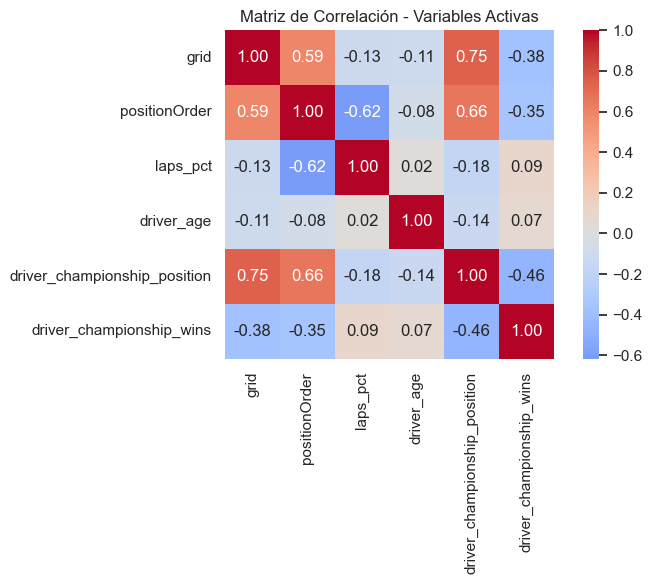

In [19]:
# Estandarización
scaler = StandardScaler()
Z = scaler.fit_transform(X)

Z_df = pd.DataFrame(Z, columns=variables_pca_activas, index=X.index)

# Matriz de correlación de variables activas estandarizadas
corr_pca = Z_df.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_pca, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Matriz de Correlación - Variables Activas")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "pca_correlacion_activas.png"))
plt.show()

## 3. Ajuste del PCA y Varianza Explicada

Se ajusta el modelo extrayendo tantas componentes como variables activas tengamos. Para definir cuántas componentes retener para el Clustering, evaluamos dos criterios:
1. **Regla de Kaiser:** Retener componentes con autovalor mayor a 1 (retienen más información que una variable original individual).
2. **Varianza Acumulada:** Se fija el umbral estándar de la literatura del 80% de varianza retenida. Esto asegura que reducimos el tamaño del dataset pero conservamos casi toda su estructura de datos original.

Componentes a retener para alcanzar 80.0% de varianza: 3


,Componente,Autovalor,Varianza Explicada,Varianza Acumulada
0,CP1,2.7997,0.4666,0.4666
1,CP2,1.1205,0.1867,0.6533
2,CP3,0.9642,0.1607,0.8140
3,CP4,0.6801,0.1133,0.9273
4,CP5,0.2526,0.0421,0.9694
5,CP6,0.1835,0.0306,1.0000


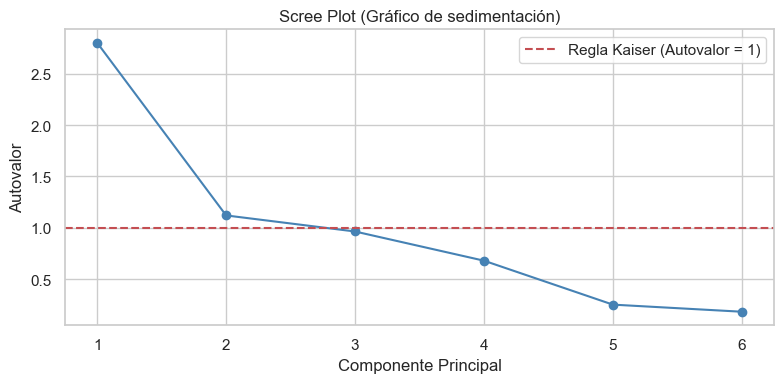

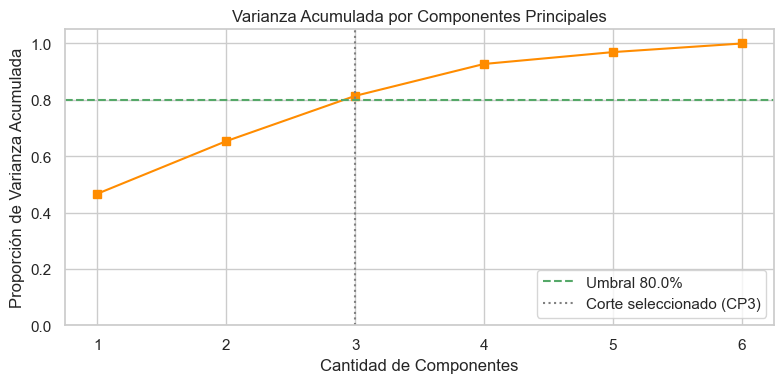

In [20]:
pca = PCA()
Z_pca = pca.fit_transform(Z)

componentes = [f"CP{i+1}" for i in range(Z_pca.shape[1])]

varianza_pca = pd.DataFrame({
    "Componente": componentes,
    "Autovalor": pca.explained_variance_,
    "Varianza Explicada": pca.explained_variance_ratio_,
    "Varianza Acumulada": np.cumsum(pca.explained_variance_ratio_)
})

# Criterio de selección: 80% de varianza acumulada
UMBRAL_VARIANZA = 0.80
K_CLUSTER = int(np.argmax(varianza_pca["Varianza Acumulada"].values >= UMBRAL_VARIANZA) + 1)
K_CLUSTER = max(K_CLUSTER, 2) # Aseguramos al menos 2 para visualizar

print(f"Componentes a retener para alcanzar {UMBRAL_VARIANZA*100}% de varianza: {K_CLUSTER}")
display(varianza_pca.round(4))

# 1. Scree Plot (Gráfico de sedimentación)
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(pca.explained_variance_) + 1), pca.explained_variance_, marker="o", color="steelblue")
plt.axhline(y=1, color='r', linestyle="--", label="Regla Kaiser (Autovalor = 1)")
plt.title("Scree Plot (Gráfico de sedimentación)")
plt.xlabel("Componente Principal")
plt.ylabel("Autovalor")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "pca_scree_plot.png"))
plt.show()

# 2. Gráfico de Varianza Acumulada
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(varianza_pca) + 1), varianza_pca["Varianza Acumulada"], marker="s", color="darkorange")
plt.axhline(y=UMBRAL_VARIANZA, color='g', linestyle="--", label=f"Umbral {UMBRAL_VARIANZA*100}%")
plt.axvline(x=K_CLUSTER, color='gray', linestyle=":", label=f"Corte seleccionado (CP{K_CLUSTER})")
plt.title("Varianza Acumulada por Componentes Principales")
plt.xlabel("Cantidad de Componentes")
plt.ylabel("Proporción de Varianza Acumulada")
plt.ylim(0, 1.05)
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "pca_varianza_acumulada.png"))
plt.show()

## 4. Interpretación: Cargas Factoriales (Loadings)

Las cargas factoriales (loadings) nos muestran la relación (correlación) entre las variables originales y las nuevas componentes.
* Vectores en la misma dirección indican correlación positiva conjunta con la componente.
* Vectores cercanos a los bordes del círculo de correlación están mejor representados en el plano bidimensional evaluado.

,CP1,CP2,CP3
grid,0.816,0.269,0.123
positionOrder,0.872,-0.343,-0.043
laps_pct,-0.477,0.807,0.216
driver_age,-0.184,-0.343,0.919
driver_championship_position,0.870,0.240,0.089
driver_championship_wins,-0.597,-0.323,-0.221


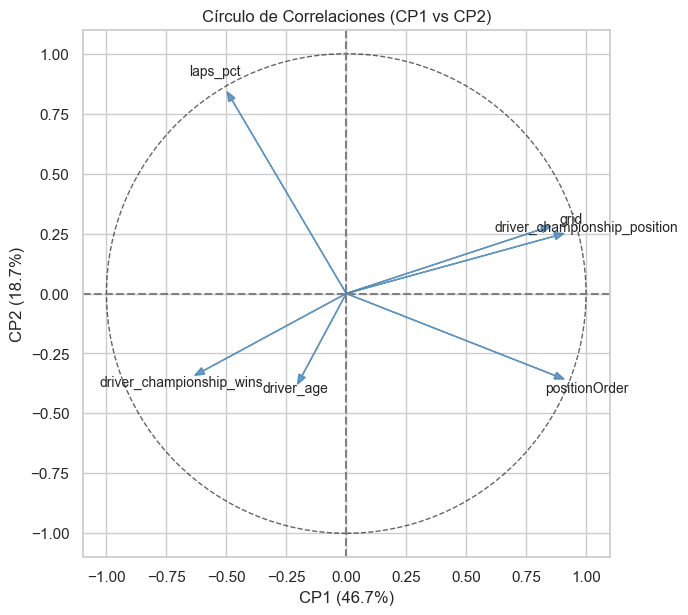

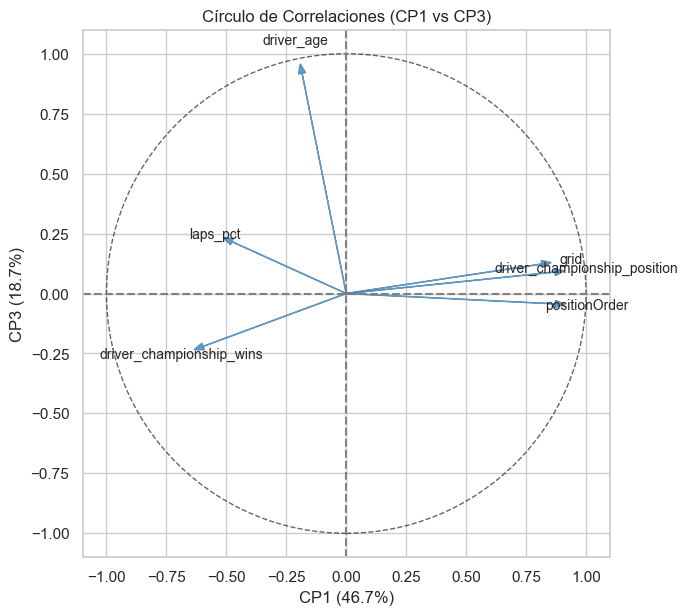

In [21]:
# Cálculo de Loadings
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)
loadings_df = pd.DataFrame(loadings, index=variables_pca_activas, columns=componentes)

display(loadings_df.iloc[:, :K_CLUSTER].round(3))

# Círculo de Correlación (CP1 vs CP2)
fig, ax = plt.subplots(figsize=(7, 7))
circle = Circle((0, 0), 1, facecolor="none", edgecolor="black", linestyle="--", alpha=0.6)
ax.add_patch(circle)
ax.axhline(0, color="gray", linestyle="--")
ax.axvline(0, color="gray", linestyle="--")

for i, variable in enumerate(loadings_df.index):
    x = loadings_df.loc[variable, "CP1"]
    y = loadings_df.loc[variable, "CP2"]
    ax.arrow(0, 0, x, y, alpha=0.8, head_width=0.03, head_length=0.04, color="steelblue")
    ax.text(x * 1.15, y * 1.15, variable, ha="center", va="center", fontsize=10)

ax.set_xlim(-1.1, 1.1)
ax.set_ylim(-1.1, 1.1)
ax.set_aspect("equal")
ax.set_xlabel(f"CP1 ({varianza_pca.loc[0, 'Varianza Explicada']*100:.1f}%)")
ax.set_ylabel(f"CP2 ({varianza_pca.loc[1, 'Varianza Explicada']*100:.1f}%)")
ax.set_title("Círculo de Correlaciones (CP1 vs CP2)")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "pca_circulo_correlacion.png"))
plt.show()

# Círculo de Correlación (CP1 vs CP3)
fig, ax = plt.subplots(figsize=(7, 7))
circle = Circle((0, 0), 1, facecolor="none", edgecolor="black", linestyle="--", alpha=0.6)
ax.add_patch(circle)
ax.axhline(0, color="gray", linestyle="--")
ax.axvline(0, color="gray", linestyle="--")

for i, variable in enumerate(loadings_df.index):
    x = loadings_df.loc[variable, "CP1"]
    y = loadings_df.loc[variable, "CP3"]
    ax.arrow(0, 0, x, y, alpha=0.8, head_width=0.03, head_length=0.04, color="steelblue")
    ax.text(x * 1.15, y * 1.15, variable, ha="center", va="center", fontsize=10)

ax.set_xlim(-1.1, 1.1)
ax.set_ylim(-1.1, 1.1)
ax.set_aspect("equal")
ax.set_xlabel(f"CP1 ({varianza_pca.loc[0, 'Varianza Explicada']*100:.1f}%)")
ax.set_ylabel(f"CP3 ({varianza_pca.loc[1, 'Varianza Explicada']*100:.1f}%)")
ax.set_title("Círculo de Correlaciones (CP1 vs CP3)")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "pca_circulo_correlacion2.png"))
plt.show()

,CP1,CP2,CP3
grid,0.238,0.064,0.016
positionOrder,0.272,0.105,0.002
laps_pct,0.081,0.582,0.048
driver_age,0.012,0.105,0.875
driver_championship_position,0.270,0.051,0.008
driver_championship_wins,0.127,0.093,0.050


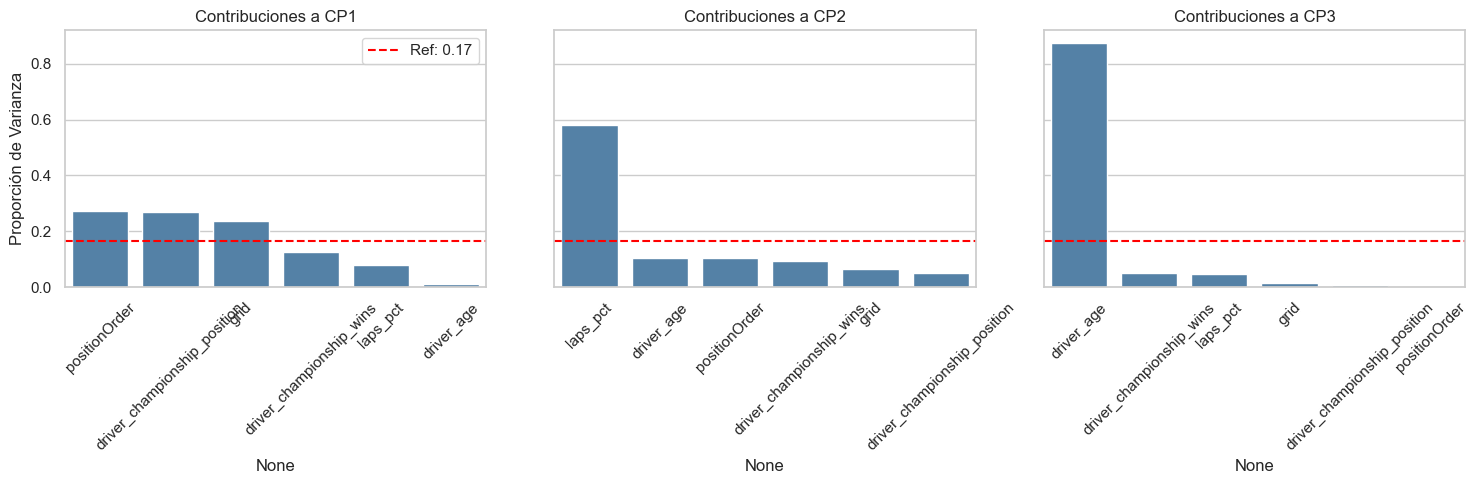

In [22]:
# Cálculo de contribuciones (cuadrado de los componentes)
contribuciones = pd.DataFrame(
    pca.components_.T ** 2,
    index=variables_pca_activas,
    columns=componentes
)

display(contribuciones.iloc[:, :K_CLUSTER].round(3))

# Gráfico de contribuciones para las componentes seleccionadas (máximo 4 para no saturar)
n_graficos = min(K_CLUSTER, 4)
fig, axes = plt.subplots(1, n_graficos, figsize=(5 * n_graficos, 5), sharey=True)

# Si solo hay 1 componente a graficar, axes no es un array, lo convertimos para poder iterar
if n_graficos == 1:
    axes = [axes]

linea_referencia = 1 / len(variables_pca_activas)

for i in range(n_graficos):
    ax = axes[i]
    cp = f"CP{i+1}"
    
    # Ordenar valores para mejor visualización
    datos_graf = contribuciones[cp].sort_values(ascending=False)
    
    sns.barplot(x=datos_graf.index, y=datos_graf.values, ax=ax, color="steelblue")
    ax.axhline(y=linea_referencia, color="red", linestyle="--", label=f"Ref: {linea_referencia:.2f}")
    
    ax.set_title(f"Contribuciones a {cp}")
    ax.set_ylabel("Proporción de Varianza")
    ax.tick_params(axis="x", rotation=45)
    
    if i == 0:
        ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "pca_contribuciones.png"))
plt.show()

## 5. Proyección de Scores y Visualización

Los *scores* son las coordenadas de cada observación en el nuevo espacio de componentes principales. 

Graficar los scores en el plano principal (CP1 vs CP2) y colorearlos según variables suplementarias (como el resultado de la carrera, la posición de largada o la época) permite validar visualmente si el PCA logró capturar patrones con sentido deportivo real.

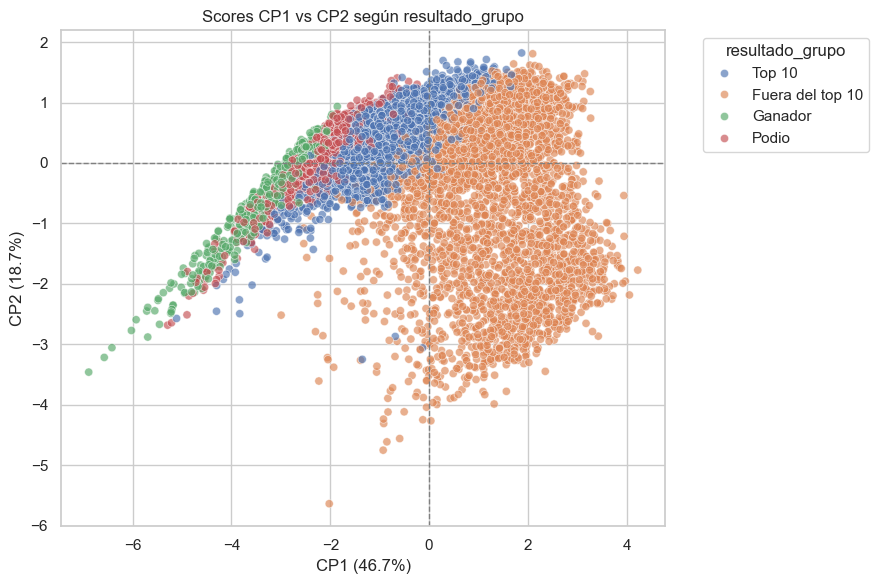

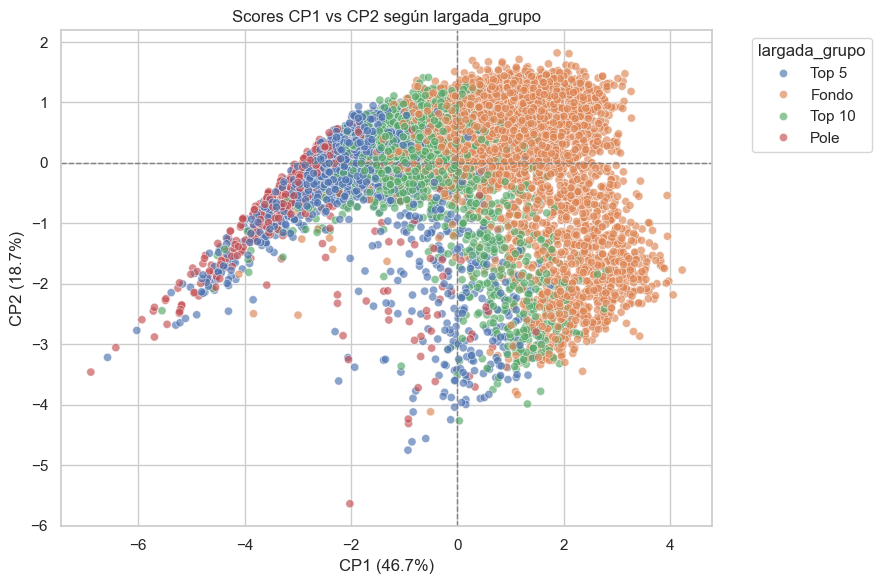

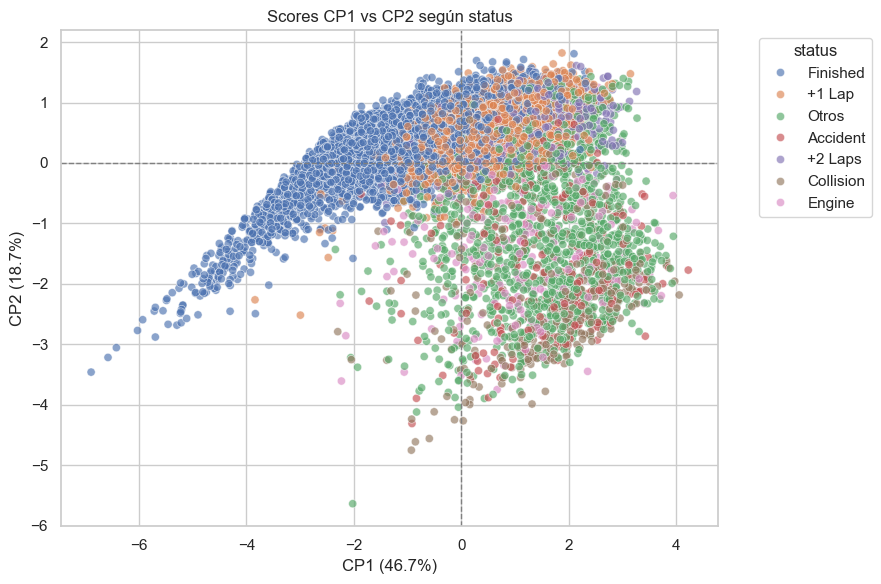

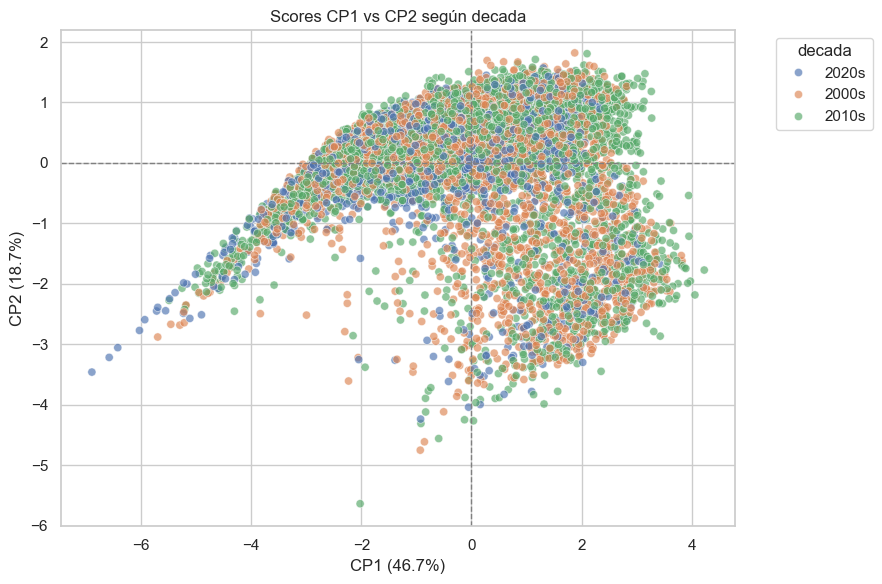

In [23]:
# Creación del DataFrame de Scores
scores_df = pd.DataFrame(Z_pca[:, :K_CLUSTER], columns=componentes[:K_CLUSTER], index=X.index)

# Unión de scores con metadata
matriz_pca_cluster = pd.concat([df_metadata, scores_df], axis=1)

# Creamos la variable 'decada' al vuelo para graficar
if "year" in matriz_pca_cluster.columns:
    matriz_pca_cluster["decada"] = (matriz_pca_cluster["year"] // 10 * 10).astype(str) + "s"

# ============================================================
# GRÁFICOS DE SCORES SEGÚN VARIABLES SUPLEMENTARIAS
# ============================================================
def graficar_scores_categoria(df_scores, categoria, cp_x="CP1", cp_y="CP2", top_n=None, nombre_archivo=None):
    if categoria not in df_scores.columns:
        print(f"La variable {categoria} no está disponible.")
        return
    
    datos = df_scores[[cp_x, cp_y, categoria]].dropna().copy()
    
    # Agrupar categorías minoritarias si se especifica top_n
    if top_n is not None:
        principales = datos[categoria].value_counts().head(top_n).index
        datos[categoria] = np.where(datos[categoria].isin(principales), datos[categoria], "Otros")
    
    plt.figure(figsize=(9, 6))
    sns.scatterplot(
        data=datos,
        x=cp_x,
        y=cp_y,
        hue=categoria,
        alpha=0.65,
        s=35
    )
    plt.axhline(0, color="gray", linestyle="--", linewidth=1)
    plt.axvline(0, color="gray", linestyle="--", linewidth=1)
    
    # Extraer varianza explicada del dataframe creado en el Bloque 8
    var_x = varianza_pca.loc[int(cp_x[2:]) - 1, 'Varianza Explicada'] * 100
    var_y = varianza_pca.loc[int(cp_y[2:]) - 1, 'Varianza Explicada'] * 100
    
    plt.xlabel(f"{cp_x} ({var_x:.1f}%)")
    plt.ylabel(f"{cp_y} ({var_y:.1f}%)")
    plt.title(f"Scores {cp_x} vs {cp_y} según {categoria}")
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", title=categoria)
    plt.tight_layout()
    
    if nombre_archivo is not None:
        plt.savefig(os.path.join(FIGURES_DIR, nombre_archivo), dpi=300, bbox_inches="tight")
    
    plt.show()

# Ejecución de los gráficos principales de interpretación
graficar_scores_categoria(matriz_pca_cluster, categoria="resultado_grupo", nombre_archivo="pca_scores_resultado.png")
graficar_scores_categoria(matriz_pca_cluster, categoria="largada_grupo", nombre_archivo="pca_scores_largada.png")
graficar_scores_categoria(matriz_pca_cluster, categoria="status", top_n=6, nombre_archivo="pca_scores_status.png")
graficar_scores_categoria(matriz_pca_cluster, categoria="decada", nombre_archivo="pca_scores_decada.png")

## 6. Guardado de la Matriz para Clustering

Una vez validado el PCA, se exporta la base de datos resultante. Esta matriz contiene tanto las variables suplementarias (útiles para perfilar los clusters posteriormente) como las componentes principales retenidas. 

Exportar únicamente las componentes necesarias (hasta alcanzar el 80% de la varianza) asegura que el algoritmo de clustering trabaje con datos limpios, ortogonales y sin problemas de colinealidad.

In [ ]:
archivo_salida_cluster = os.path.join(DATA_PROCESSED, "formula1_pca_scores.csv")
matriz_pca_cluster.to_csv(archivo_salida_cluster, index=False)

print(f"Matriz PCA guardada con éxito en: {archivo_salida_cluster}")
print(f"Dimensiones finales para clustering: {matriz_pca_cluster.shape}")

Matriz PCA guardada con éxito en: ../data/processed/formula1_pca_scores_cluster.csv
Dimensiones finales para clustering: (9760, 13)
